In [ ]:
import kagglehub
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("prachi13/customer-analytics")

print("Path to dataset files:", path)

# Load dataset into df
df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

Using Colab cache for faster access to the 'customer-analytics' dataset.
Path to dataset files: /kaggle/input/customer-analytics


# 1. Add New Features (Feature Engineering)

In [ ]:
# 1. Cost-to-Weight Ratio
df['Cost_to_Weight_Ratio'] = df['Cost_of_the_Product'] / df['Weight_in_gms']

In [ ]:
# 2. Discount Percentage of Cost
df['Discount_Percentage'] = (df['Discount_offered'] / df['Cost_of_the_Product']) * 100

In [ ]:
# 3. Total Customer Engagement (prior purchases + care calls)
df['Total_Engagement'] = df['Customer_care_calls'] + df['Prior_purchases']

In [ ]:
# 4. High Value Order Flag (binary)
df['High_Value_Order'] = np.where(df['Cost_of_the_Product'] > 250, 1, 0)

In [ ]:
# 5. Weight Category (Light, Medium, Heavy)
df['Weight_Category'] = pd.cut(df['Weight_in_gms'],
                               bins=[0, 2000, 4000, np.inf],
                               labels=['Light', 'Medium', 'Heavy'])

In [ ]:
# 6. Discount Flag (binary)
df['Discount_Flag'] = np.where(df['Discount_offered'] > 0, 1, 0)

In [ ]:
# 7. Shipment Speed Indicator (ordinal encoding)
shipment_speed_map = {'Road': 1, 'Ship': 2, 'Flight': 3}
df['Shipment_Speed'] = df['Mode_of_Shipment'].map(shipment_speed_map)

In [ ]:
# 8. Is_Premium_Product (binary: high importance + high cost)
df['Is_Premium_Product'] = np.where((df['Product_importance'] == 'high') &
                                    (df['Cost_of_the_Product'] > 220), 1, 0)

In [ ]:
# 9. Effective_Cost_After_Discount
df['Effective_Cost_After_Discount'] = df['Cost_of_the_Product'] - df['Discount_offered']

In [ ]:
# 10. Calls_per_Purchase (normalized customer care calls by prior purchases)
df['Calls_per_Purchase'] = df['Customer_care_calls'] / (df['Prior_purchases'] + 1)

In [ ]:
# 11. Weight_per_Purchase (normalized weight by prior purchases)
df['Weight_per_Purchase'] = df['Weight_in_gms'] / (df['Prior_purchases'] + 1)

In [ ]:
# 12. Customer_Rating_Binary (1 if rating >= 4, else 0)
df['Customer_Rating_Binary'] = np.where(df['Customer_rating'] >= 4, 1, 0)

In [ ]:
# Save the updated dataset
df.to_csv("/content/customer_analytics_with_new_features.csv", index=False)

print("New dataset with engineered features saved as 'customer_analytics_with_new_features.csv'")
print("Shape of new dataset:", df.shape)

New dataset with engineered features saved as 'customer_analytics_with_new_features.csv'
Shape of new dataset: (10999, 23)


## 🔧 Feature Engineering Summary

| Feature Name                  | Formula / Definition                                                | Purpose / Business Logic                                                                 |
|--------------------------------|---------------------------------------------------------------------|------------------------------------------------------------------------------------------|
| `Cost_to_Weight_Ratio`         | `Cost_of_the_Product / Weight_in_gms`                               | Identifies expensive but lightweight products that may be sensitive in shipping.          |
| `Discount_Percentage`          | `(Discount_offered / Cost_of_the_Product) * 100`                    | Measures relative discount; high discounts may correlate with delayed deliveries.         |
| `Total_Engagement`             | `Customer_care_calls + Prior_purchases`                             | Captures customer’s interaction/loyalty and overall engagement with company.              |
| `High_Value_Order`             | `1 if Cost_of_the_Product > 250 else 0`                             | Flags premium orders that may get priority in shipping.                                   |
| `Weight_Category`              | Bins: Light (<2000g), Medium (2000–4000g), Heavy (>4000g)           | Categorizes orders by shipping weight, reflecting logistics handling differences.         |
| `Discount_Flag`                | `1 if Discount_offered > 0 else 0`                                  | Flags whether the product was purchased with a discount.                                  |
| `Shipment_Speed`               | Road=1, Ship=2, Flight=3                                            | Converts shipment mode into an ordinal feature representing delivery speed.               |
| `Is_Premium_Product`           | `1 if Product_importance == "high" and Cost > 220 else 0`           | Identifies premium products that are both costly and marked important by company.         |
| `Effective_Cost_After_Discount`| `Cost_of_the_Product - Discount_offered`                            | Represents the true cost paid after applying discount.                                    |
| `Calls_per_Purchase`           | `Customer_care_calls / (Prior_purchases + 1)`                       | Normalizes support calls by purchase history to measure customer dependency.              |
| `Weight_per_Purchase`          | `Weight_in_gms / (Prior_purchases + 1)`                             | Normalizes shipment weight by past purchases, useful for heavy repeat customers.          |
| `Customer_Rating_Binary`       | `1 if Customer_rating >= 4 else 0`                                  | Converts rating into binary signal: satisfied (≥4) vs unsatisfied (<4).                   |


#2. Feature Selection Methods

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("customer_analytics_with_new_features.csv")

# Define features and target
X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

### Filter Methods (Statistical Approaches)

In [ ]:
# 1. Variance Threshold - removes features with very low variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X.select_dtypes(include='number'))
print("Selected features:", X.select_dtypes(include='number').columns[selector.get_support()])

Selected features: Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Discount_Percentage', 'Total_Engagement', 'High_Value_Order',
       'Is_Premium_Product', 'Effective_Cost_After_Discount',
       'Calls_per_Purchase', 'Weight_per_Purchase', 'Customer_Rating_Binary'],
      dtype='object')


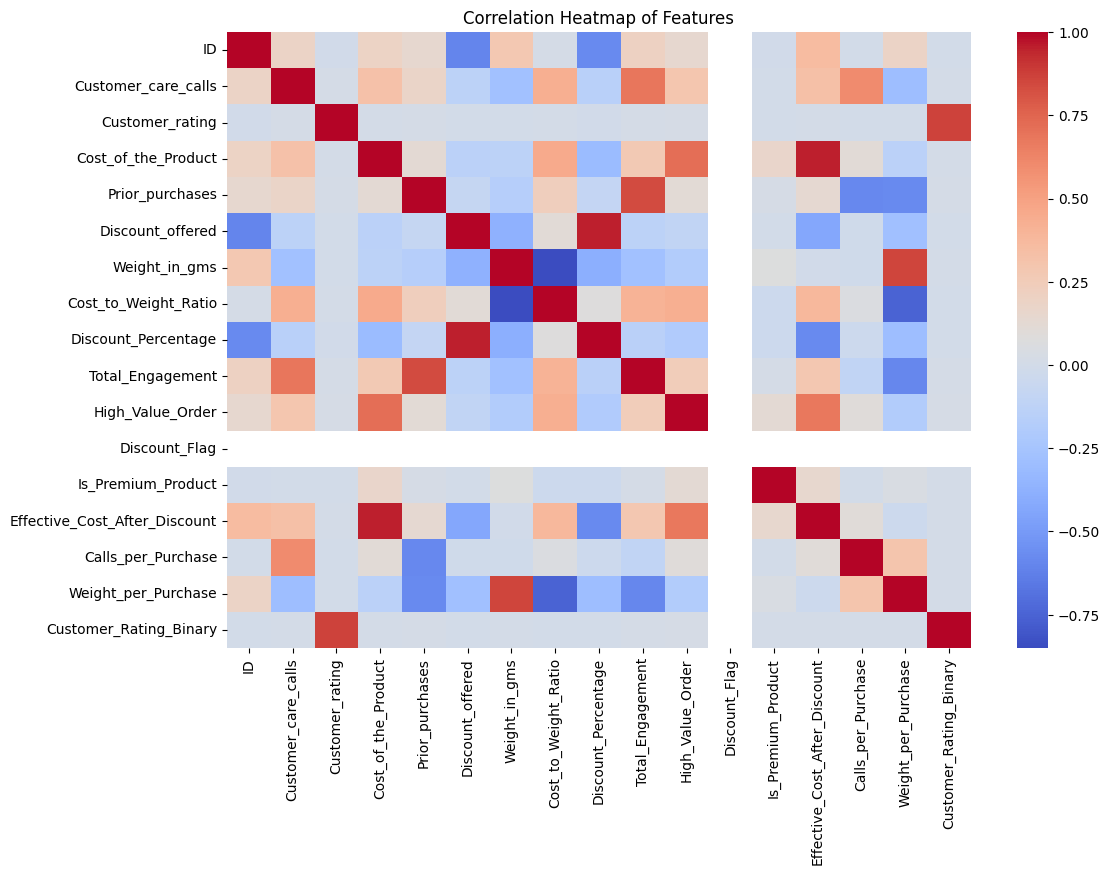

In [ ]:
# 2. Correlation Heatmap - check highly correlated features
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()

In [ ]:
# 3. Variance Inflation Factor (VIF) - detect multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_num = X.select_dtypes(include='number').fillna(0)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                          Feature         VIF
1             Customer_care_calls         inf
13  Effective_Cost_After_Discount         inf
3             Cost_of_the_Product         inf
4                 Prior_purchases         inf
5                Discount_offered         inf
9                Total_Engagement         inf
11                  Discount_Flag  163.978399
6                   Weight_in_gms   22.626642
15            Weight_per_Purchase   22.089604
8             Discount_Percentage   18.478527
14             Calls_per_Purchase   12.287212
7            Cost_to_Weight_Ratio    9.098052
16         Customer_Rating_Binary    3.953524
2                 Customer_rating    3.953142
10               High_Value_Order    2.158371
0                              ID    1.856385
12             Is_Premium_Product    1.052239


In [ ]:
# 4. Chi-Square Test - categorical features vs target
from sklearn.feature_selection import chi2
X_cat = pd.get_dummies(X.select_dtypes(include='object'))
chi_scores = chi2(X_cat, y)
chi2_results = pd.DataFrame({'Feature': X_cat.columns, 'Chi2 Score': chi_scores[0], 'p-value': chi_scores[1]})
print(chi2_results.sort_values(by="Chi2 Score", ascending=False).head(10))

                      Feature   Chi2 Score        p-value
15     Weight_Category_Medium  1205.178311  4.569933e-264
13      Weight_Category_Heavy   672.835889  2.414824e-148
14      Weight_Category_Light    88.398881   5.350106e-21
8     Product_importance_high    11.106674   8.601762e-04
0           Warehouse_block_A     0.795620   3.724062e-01
10  Product_importance_medium     0.769316   3.804286e-01
6       Mode_of_Shipment_Road     0.543731   4.608906e-01
9      Product_importance_low     0.335174   5.626284e-01
1           Warehouse_block_B     0.238925   6.249834e-01
5     Mode_of_Shipment_Flight     0.176215   6.746462e-01


In [ ]:
# 5. ANOVA Test - compare group means for numerical features vs target
from sklearn.feature_selection import f_classif
f_test, p_vals = f_classif(X_num, y)
anova_results = pd.DataFrame({'Feature': X_num.columns, 'F-Score': f_test, 'p-value': p_vals})
print(anova_results.sort_values(by="F-Score", ascending=False).head(10))

                          Feature      F-Score        p-value
0                              ID  2245.979758   0.000000e+00
5                Discount_offered  2058.842985   0.000000e+00
8             Discount_Percentage  1861.505746   0.000000e+00
6                   Weight_in_gms   856.401798  2.354658e-181
15            Weight_per_Purchase   483.458826  6.739309e-105
13  Effective_Cost_After_Discount   406.734875   7.531503e-89
7            Cost_to_Weight_Ratio    84.026500   5.748903e-20
9                Total_Engagement    67.612926   2.213278e-16
3             Cost_of_the_Product    59.873829   1.099886e-14
1             Customer_care_calls    49.775450   1.827535e-12


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [11] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
# 6. F-Test - compare variances of two features
from scipy.stats import f
feature1, feature2 = X_num['Cost_of_the_Product'], X_num['Discount_offered']
f_stat = np.var(feature1) / np.var(feature2)
print("F-statistic (Cost vs Discount):", f_stat)

F-statistic (Cost vs Discount): 8.796306214707936


In [ ]:
# 7. Z-Test - test mean difference for n >= 30
from statsmodels.stats.weightstats import ztest
z_stat, p_val = ztest(X_num['Cost_of_the_Product'], value=200)
print("Z-test for mean=200 -> Z-stat:", z_stat, "p-value:", p_val)

Z-test for mean=200 -> Z-stat: 22.249933023714174 p-value: 1.1296130569759058e-109


In [ ]:
# 8. T-Test - test mean difference when n < 30 (taking sample)
from scipy.stats import ttest_1samp
sample = X_num['Weight_in_gms'].sample(25, random_state=42)
t_stat, p_val = ttest_1samp(sample, 3000)
print("T-test on small sample (Weight vs mean=3000):", t_stat, "p-value:", p_val)

T-test on small sample (Weight vs mean=3000): 1.6175946963479908 p-value: 0.11881927316163325


In [ ]:
# 9. Mutual Information - captures nonlinear relationships
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X_num, y)
mi_scores = pd.Series(mi, index=X_num.columns).sort_values(ascending=False)
print("Top features by Mutual Information:\n", mi_scores.head(10))

Top features by Mutual Information:
 ID                               0.186273
Discount_offered                 0.155026
Discount_Percentage              0.138570
Weight_in_gms                    0.120909
Cost_to_Weight_Ratio             0.119278
Weight_per_Purchase              0.052503
Effective_Cost_After_Discount    0.025540
Calls_per_Purchase               0.013524
Total_Engagement                 0.009657
Prior_purchases                  0.005222
dtype: float64


In [ ]:
# 10. Hypothesis Testing Summary - p-values vs alpha=0.05
alpha = 0.05
significant_features = anova_results[anova_results['p-value'] < alpha]['Feature']
print("Features significant at alpha=0.05:\n", significant_features.tolist())

Features significant at alpha=0.05:
 ['ID', 'Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Cost_to_Weight_Ratio', 'Discount_Percentage', 'Total_Engagement', 'High_Value_Order', 'Effective_Cost_After_Discount', 'Weight_per_Purchase']


### Embedded Methods (Model-Based Importance)

In [ ]:
# 1. Logistic Regression with L1 (Lasso)
from sklearn.linear_model import LogisticRegression
lasso = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
lasso.fit(X_num.fillna(0), y)
lasso_coef = pd.Series(lasso.coef_[0], index=X_num.columns)
print("Top Lasso Features:\n", lasso_coef.sort_values(ascending=False).head(10))

Top Lasso Features:
 Discount_Flag                    1.141795
Calls_per_Purchase               1.029237
Is_Premium_Product               0.149076
Discount_Percentage              0.074546
Discount_offered                 0.051723
Customer_rating                  0.047736
Effective_Cost_After_Discount    0.002354
Cost_of_the_Product              0.000408
Prior_purchases                  0.000000
ID                              -0.000136
dtype: float64


In [ ]:
# 2. Logistic Regression with L2 (Ridge)
ridge = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
ridge.fit(X_num.fillna(0), y)
ridge_coef = pd.Series(ridge.coef_[0], index=X_num.columns)
print("Top Ridge Features:\n", ridge_coef.sort_values(ascending=False).head(10))

Top Ridge Features:
 Calls_per_Purchase     0.969068
Discount_Flag          0.750238
Is_Premium_Product     0.192757
Discount_Percentage    0.089037
Customer_rating        0.057403
Prior_purchases        0.041723
Discount_offered       0.031282
Cost_of_the_Product    0.016343
Weight_in_gms          0.000010
ID                    -0.000146
dtype: float64


In [ ]:
# 3. Decision Tree Feature Importance
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_num.fillna(0), y)
dt_importances = pd.Series(dt.feature_importances_, index=X_num.columns)
print("Top Decision Tree Features:\n", dt_importances.sort_values(ascending=False).head(10))

Top Decision Tree Features:
 ID                               0.400549
Cost_to_Weight_Ratio             0.099801
Weight_per_Purchase              0.098157
Discount_Percentage              0.093542
Weight_in_gms                    0.081130
Effective_Cost_After_Discount    0.055643
Cost_of_the_Product              0.052836
Total_Engagement                 0.024851
Customer_rating                  0.024783
Calls_per_Purchase               0.019458
dtype: float64


In [ ]:
# 4. Random Forest Feature Importance
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_num.fillna(0), y)
rf_importances = pd.Series(rf.feature_importances_, index=X_num.columns)
print("Top Random Forest Features:\n", rf_importances.sort_values(ascending=False).head(10))

Top Random Forest Features:
 ID                               0.207339
Discount_Percentage              0.120048
Weight_in_gms                    0.115684
Cost_to_Weight_Ratio             0.100267
Weight_per_Purchase              0.090900
Discount_offered                 0.088402
Effective_Cost_After_Discount    0.075966
Cost_of_the_Product              0.067377
Customer_rating                  0.029528
Calls_per_Purchase               0.029192
dtype: float64


In [ ]:
# 5. Extra Trees Feature Importance
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(random_state=42)
et.fit(X_num.fillna(0), y)
et_importances = pd.Series(et.feature_importances_, index=X_num.columns)
print("Top Extra Trees Features:\n", et_importances.sort_values(ascending=False).head(10))

Top Extra Trees Features:
 ID                               0.165286
Weight_in_gms                    0.110032
Discount_offered                 0.102552
Discount_Percentage              0.101512
Cost_to_Weight_Ratio             0.095632
Weight_per_Purchase              0.083661
Effective_Cost_After_Discount    0.076151
Cost_of_the_Product              0.071285
Customer_rating                  0.042292
Total_Engagement                 0.033855
dtype: float64


In [ ]:
# 6. Gradient Boosting Feature Importance
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_num.fillna(0), y)
gb_importances = pd.Series(gb.feature_importances_, index=X_num.columns)
print("Top Gradient Boosting Features:\n", gb_importances.sort_values(ascending=False).head(10))

Top Gradient Boosting Features:
 ID                               0.899188
Cost_to_Weight_Ratio             0.025418
Weight_in_gms                    0.017929
Discount_Percentage              0.015808
Weight_per_Purchase              0.012161
Effective_Cost_After_Discount    0.009959
Cost_of_the_Product              0.005280
Discount_offered                 0.003211
Customer_rating                  0.003168
Calls_per_Purchase               0.002588
dtype: float64


In [ ]:
# 7. XGBoost Feature Importance
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_num.fillna(0), y)
xgb_importances = pd.Series(xgb.feature_importances_, index=X_num.columns)
print("Top XGBoost Features:\n", xgb_importances.sort_values(ascending=False).head(10))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:41:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Top XGBoost Features:
 ID                               0.337995
Customer_care_calls              0.055696
Cost_to_Weight_Ratio             0.055215
Discount_Percentage              0.055166
Prior_purchases                  0.054210
Effective_Cost_After_Discount    0.053526
Calls_per_Purchase               0.049498
Is_Premium_Product               0.049120
Cost_of_the_Product              0.049113
Customer_rating                  0.049112
dtype: float32


In [ ]:
# 8. Permutation Importance (with Random Forest)
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, X_num.fillna(0), y, n_repeats=10, random_state=42)
perm_importances = pd.Series(perm.importances_mean, index=X_num.columns)
print("Top Permutation Importances:\n", perm_importances.sort_values(ascending=False).head(10))

Top Permutation Importances:
 ID                               0.156778
Weight_in_gms                    0.093390
Discount_Percentage              0.040422
Cost_to_Weight_Ratio             0.030676
Weight_per_Purchase              0.030057
Discount_offered                 0.026330
Effective_Cost_After_Discount    0.010746
Cost_of_the_Product              0.010646
Customer_rating                  0.010146
Calls_per_Purchase               0.001018
dtype: float64


In [ ]:
# 9. SelectFromModel with Gradient Boosting - Embedded Method
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_num.fillna(0), y)

sfm = SelectFromModel(gb, prefit=True, threshold="median")
selected_features = X_num.columns[sfm.get_support()]

print("Gradient Boosting Selected Features:", list(selected_features))

Gradient Boosting Selected Features: ['ID', 'Customer_rating', 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms', 'Cost_to_Weight_Ratio', 'Discount_Percentage', 'Effective_Cost_After_Discount', 'Weight_per_Purchase']


In [ ]:
# 10. Stability Selection - average feature importance across runs
importances_list = []
for seed in [10, 20, 30, 40, 50]:
    rf_temp = RandomForestClassifier(random_state=seed)
    rf_temp.fit(X_num.fillna(0), y)
    importances_list.append(rf_temp.feature_importances_)
stability = pd.DataFrame(importances_list, columns=X_num.columns).mean().sort_values(ascending=False)
print("Stable Importances Across Runs:\n", stability.head(10))

Stable Importances Across Runs:
 ID                               0.199132
Discount_Percentage              0.121967
Weight_in_gms                    0.112256
Cost_to_Weight_Ratio             0.102930
Weight_per_Purchase              0.093356
Discount_offered                 0.092205
Effective_Cost_After_Discount    0.072869
Cost_of_the_Product              0.068148
Customer_rating                  0.030570
Calls_per_Purchase               0.029158
dtype: float64


### Wrapper Methods (Iterative Search)

In [ ]:
# 1. SelectFromModel with Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_num.fillna(0), y)
sfm_dt = SelectFromModel(dt, prefit=True, threshold="median")

selected_features = list(X_num.columns[sfm_dt.get_support()])

print("Decision Tree Selected Features:")
for feature in selected_features:
    print(feature)

Decision Tree Selected Features:
ID
Customer_care_calls
Customer_rating
Cost_of_the_Product
Prior_purchases
Discount_offered
Weight_in_gms
Cost_to_Weight_Ratio
Discount_Percentage
Total_Engagement
High_Value_Order
Discount_Flag
Is_Premium_Product
Effective_Cost_After_Discount
Calls_per_Purchase
Weight_per_Purchase
Customer_Rating_Binary


In [ ]:
# 2. SelectFromModel with Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_num.fillna(0), y)
sfm_rf = SelectFromModel(rf, prefit=True, threshold="median")

selected_features = list(X_num.columns[sfm_rf.get_support()])
print("Random Forest Selected Features:")
for f in selected_features:
    print(f)

Random Forest Selected Features:
ID
Customer_rating
Cost_of_the_Product
Discount_offered
Weight_in_gms
Cost_to_Weight_Ratio
Discount_Percentage
Effective_Cost_After_Discount
Weight_per_Purchase


In [ ]:
# 3. SelectFromModel with Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_num.fillna(0), y)
sfm_gb = SelectFromModel(gb, prefit=True, threshold="median")

print("Gradient Boosting Selected Features:")
for f in X_num.columns[sfm_gb.get_support()]:
    print(f)

Gradient Boosting Selected Features:
ID
Customer_rating
Cost_of_the_Product
Discount_offered
Weight_in_gms
Cost_to_Weight_Ratio
Discount_Percentage
Effective_Cost_After_Discount
Weight_per_Purchase


In [56]:
# 4. Top-K Feature Selection using Random Forest Importance
rf = RandomForestClassifier(n_estimators=30, random_state=42)
rf.fit(X_num.fillna(0), y)

top_features = X_num.columns[np.argsort(rf.feature_importances_)[-10:]]

print("Top 10 Features by RF Importance:")
for f in top_features:
    print(f)

Top 10 Features by RF Importance:
Calls_per_Purchase
Customer_rating
Cost_of_the_Product
Effective_Cost_After_Discount
Weight_per_Purchase
Cost_to_Weight_Ratio
Discount_offered
Weight_in_gms
Discount_Percentage
ID


In [55]:
# 5. Quick Backward Elimination using Variance
low_var = X_num.var().sort_values().head(5).index
X_backward = X_num.drop(low_var, axis=1)

print("Removed Low-Variance Features:")
for f in low_var:
    print(f)

print("\nRemaining Features:")
for f in X_backward.columns:
    print(f)

Removed Low-Variance Features:
Discount_Flag
Cost_to_Weight_Ratio
Is_Premium_Product
Calls_per_Purchase
High_Value_Order

Remaining Features:
ID
Customer_care_calls
Customer_rating
Cost_of_the_Product
Prior_purchases
Discount_offered
Weight_in_gms
Discount_Percentage
Total_Engagement
Effective_Cost_After_Discount
Weight_per_Purchase
Customer_Rating_Binary


In [ ]:
# 6. Quick Forward Selection (Random Forest Top 10 by importance)
rf_top10 = X_num.columns[np.argsort(rf.feature_importances_)[-10:]]

print("Forward Selection Approx (Top 10 RF):")
for f in rf_top10:
    print(f)

Forward Selection Approx (Top 10 RF):
Calls_per_Purchase
Customer_rating
Cost_of_the_Product
Effective_Cost_After_Discount
Weight_per_Purchase
Cost_to_Weight_Ratio
Discount_offered
Weight_in_gms
Discount_Percentage
ID


In [ ]:
# 7. Quick Backward Elimination (drop 5 lowest variance features)
low_var = X_num.var().sort_values().head(5).index
X_backward = X_num.drop(low_var, axis=1)

print("Backward Elimination Approx - Removed:")
for f in low_var:
    print(f)

print("\nRemaining Features:")
for f in X_backward.columns:
    print(f)

Backward Elimination Approx - Removed:
Discount_Flag
Cost_to_Weight_Ratio
Is_Premium_Product
Calls_per_Purchase
High_Value_Order

Remaining Features:
ID
Customer_care_calls
Customer_rating
Cost_of_the_Product
Prior_purchases
Discount_offered
Weight_in_gms
Discount_Percentage
Total_Engagement
Effective_Cost_After_Discount
Weight_per_Purchase
Customer_Rating_Binary


In [ ]:
# 8. Wrapper-style Random Subset Evaluation
import random
subset = random.sample(list(X_num.columns), 10)
rf = RandomForestClassifier(n_estimators=30, random_state=42)
rf.fit(X_num[subset].fillna(0), y)

print("Random Subset of Features:")
for f in subset:
    print(f)
print("\nAccuracy with random subset:", rf.score(X_num[subset].fillna(0), y))

Random Subset of Features:
Total_Engagement
Discount_Percentage
Customer_care_calls
Prior_purchases
Discount_Flag
Cost_to_Weight_Ratio
Calls_per_Purchase
Effective_Cost_After_Discount
High_Value_Order
Weight_per_Purchase

Accuracy with random subset: 0.9992726611510138


In [ ]:
# 9. Compare Wrapper (RFE RF) vs Embedded (RF importance)
print("Wrapper (RFE RF) Features:")
for f in X_num.columns[rfe_rf.support_]:
    print(f)

print("\nEmbedded (RF Top 10) Features:")
for f in rf_top10:
    print(f)

Wrapper (RFE RF) Features:
ID
Customer_rating
Cost_of_the_Product
Discount_offered
Weight_in_gms
Cost_to_Weight_Ratio
Discount_Percentage
Effective_Cost_After_Discount
Calls_per_Purchase
Weight_per_Purchase

Embedded (RF Top 10) Features:
Calls_per_Purchase
Customer_rating
Cost_of_the_Product
Effective_Cost_After_Discount
Weight_per_Purchase
Cost_to_Weight_Ratio
Discount_offered
Weight_in_gms
Discount_Percentage
ID


In [ ]:
# 10. Stability Selection with RF (average importances across runs)
importances_list = []
for seed in [10, 20, 30]:
    rf_temp = RandomForestClassifier(n_estimators=30, random_state=seed)
    rf_temp.fit(X_num.fillna(0), y)
    importances_list.append(rf_temp.feature_importances_)

stability = pd.DataFrame(importances_list, columns=X_num.columns).mean().sort_values(ascending=False)

print("Stable Features Across Runs:")
for f in stability.head(10).index:
    print(f)

Stable Features Across Runs:
ID
Discount_Percentage
Weight_in_gms
Cost_to_Weight_Ratio
Weight_per_Purchase
Discount_offered
Effective_Cost_After_Discount
Cost_of_the_Product
Customer_rating
Calls_per_Purchase
